# 中文分词 + TF-IDF + KMeans 评论聚类

本 notebook 用于在不预先指定类别的情况下，通过传统文本挖掘方法自动发现酒店评论主题。流程包括：读取分类前数据、中文分词、TF-IDF 向量化、KMeans 聚类、聚类效果评估、主题关键词与代表评论提取。

In [1]:
import re
from pathlib import Path

import jieba
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

plt.rcParams["axes.unicode_minus"] = False

## 1. Read filtered comments

In [2]:
DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / "filtered_comments.csv"
OUTPUT_DIR = Path("tfidf_result")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Input data file not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
source_path = DATA_PATH

# Do not use existing category labels as features for unsupervised clustering.
df = df.drop(columns=["categories"], errors="ignore")

# Keep compatibility with the old notebook column names.
df = df.rename(columns={
    "comment_len": "comment_length",
    "log_comment_len": "log_comment_length",
})

if "_id" in df.columns:
    df = df.set_index("_id")

df["comment"] = df["comment"].fillna("").astype(str)
df = df[df["comment"].str.strip().ne("")].copy()

print(f"Data source: {source_path}")
print(f"Comment count: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Data source: data/filtered_comments.csv
Comment count: 2171
Columns: ['comment', 'images', 'score', 'publish_date', 'room_type', 'fuzzy_room_type', 'travel_type', 'comment_length', 'log_comment_length', 'useful_count', 'log_useful_count', 'review_count', 'log_review_count', 'quality_score']


,comment,images,score,publish_date,room_type,fuzzy_room_type,travel_type,comment_length,log_comment_length,useful_count,log_useful_count,review_count,log_review_count,quality_score
_id,,,,,,,,,,,,,,
68027895e3c98b0941765706,房间非常好 装修很厚重奢华 一开始看评论 看酒店自己po的照片 感觉跟快捷酒店一样 有些害怕...,"[ ""https://dimg04.c-ctrip.com/images/0230y1200...",5.0,2025-04-05,红棉大床套房,套房,家庭亲子,320,5.771441,0,0.000000,7,2.079442,9
68027895e3c98b0941765707,花园酒店广州的老牌五星，一直期望的入住。房间我入住时要求前台帮我升级了新装修的房间，粤韵。其...,"[ ""https://dimg04.c-ctrip.com/images/023461200...",4.2,2025-04-07,红棉大床套房,套房,独自旅行,223,5.411646,0,0.000000,28,3.367296,8
68027895e3c98b0941765708,一进酒店就感觉来到了桃花源，迎宾人员都很热情，彬彬有礼，房间也非常不错，床品都很舒服，洗嗽用...,"[ ""https://dimg04.c-ctrip.com/images/023011200...",5.0,2025-04-15,花园双床房,双床房,商务出差,124,4.828314,0,0.000000,11,2.484907,8
68027895e3c98b0941765709,总体来说很好。早餐有两个地方可以用，最上层的旋转餐厅用早餐感觉还是非常不错的。另外酒店的后花...,"[ ""https://dimg04.c-ctrip.com/images/0231r1200...",5.0,2025-04-15,花园大床房,大床房,情侣出游,99,4.605170,1,0.693147,18,2.944439,9
68027895e3c98b094176570a,多年没来广州，临时起意过来住花园酒店，环境舒适，没有想象中的老式，全员服务在线，礼貌周到，给...,"[ ""https://dimg04.c-ctrip.com/images/0231o1200...",5.0,2025-04-06,花园双床房,双床房,家庭亲子,165,5.111988,0,0.000000,13,2.639057,9


## 2. 中文分词与停用词

这里使用 `jieba` 分词，并过滤常见停用词、纯数字和长度过短的词。停用词表可以根据聚类结果继续扩充。

In [3]:
STOPWORDS = set("""
的 了 和 是 就 都 而 及 与 着 或 一个 一些 这个 那个 这里 那里 我们 你们 他们
很 非常 比较 真的 还是 感觉 觉得 但是 不过 因为 所以 如果 以及 还有 没有
酒店 房间 入住 评论 客人 客服 携程 广州 花园 可以 不是 一下 一直 这家
也 都 会 有 在 对 中 上 下 里 到 去 来 让 给 被 从 把 还 又 再 更 最
""".split())

def clean_text(text):
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"[^\u4e00-\u9fa5a-zA-Z0-9]+", " ", text)
    return text.strip()

def jieba_tokenizer(text):
    words = jieba.lcut(clean_text(text))
    tokens = []
    for word in words:
        word = word.strip().lower()
        if len(word) <= 1:
            continue
        if word in STOPWORDS:
            continue
        if word.isdigit():
            continue
        tokens.append(word)
    return tokens

sample_text = df["comment"].iloc[0]
print("原文示例：")
print(sample_text[:300])
print("\n分词示例：")
print(jieba_tokenizer(sample_text)[:80])

Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache


原文示例：
房间非常好 装修很厚重奢华 一开始看评论 看酒店自己po的照片 感觉跟快捷酒店一样 有些害怕  但来了之后 真的很惊喜 装修很厚重 很奢华 跟一些老牌的日系酒店 （帝国酒店）之类的感觉 没想到在广州也有这样开业时间很长但仍然配套跟得上的酒店。。
服务很好！ 门童拿行李迎宾开门 比一些国际连锁的五星要好多了。 退房时候liren还帮忙直接登记了退房 不用排队了。什么时候北京的酒店服务也能跟上广州呢。。。

另外吃的真的很好

晚上去楼顶旋转自助吃 螃蟹腿鲍鱼进口生蚝 吃撑了 还有最爱吃的金蒜牛肉 做的真的很好吃 比北京第六季那种什么海鲜都拿来涮的自助强好多

酒店里还有花园 大锦鲤吃的真的好 又

分词示例：


Loading model cost 0.960 seconds.
Prefix dict has been built successfully.


['装修', '厚重', '奢华', '开始', '自己', 'po', '照片', '快捷酒店', '一样', '有些', '害怕', '但来', '之后', '惊喜', '装修', '厚重', '奢华', '老牌', '日系', '帝国', '之类', '没想到', '这样', '开业', '时间', '很长', '仍然', '配套', '跟得上', '服务', '门童', '行李', '迎宾', '开门', '国际', '连锁', '五星', '好多', '退房', '时候', 'liren', '帮忙', '直接', '登记', '退房', '不用', '排队', '什么', '时候', '北京', '服务', '跟上', '另外', '晚上', '楼顶', '旋转', '自助', '螃蟹', '鲍鱼', '进口', '最爱', '金蒜', '牛肉', '好吃', '北京', '第六', '那种', '什么', '海鲜', '拿来', '自助', '好多', '锦鲤', '总体', '来说', '物超所值', '下次', '还来']


## 3. TF-IDF 向量化

`min_df` 用于过滤出现太少的词，`max_df` 用于过滤过于常见的词；`max_features` 控制词表规模。

In [4]:
vectorizer = TfidfVectorizer(
    tokenizer=jieba_tokenizer,
    token_pattern=None,
    max_features=5000,
    min_df=3,
    max_df=0.8,
    ngram_range=(1, 2),
)

X = vectorizer.fit_transform(df["comment"])
terms = np.array(vectorizer.get_feature_names_out())

print(f"TF-IDF 矩阵形状：{X.shape}")
print(f"词表大小：{len(terms)}")

TF-IDF 矩阵形状：(2171, 5000)
词表大小：5000


## 4. 选择聚类数 k

下面用 inertia 和 silhouette score 辅助观察聚类数。`silhouette_score` 越高通常表示簇间区分更清晰，但文本聚类中不必只追求最高值，还要结合主题可解释性。

,k,inertia,silhouette
0,2,2112.046969,0.003715
1,3,2103.888286,0.006345
2,4,2097.621906,0.007703
3,5,2090.998744,0.008934
4,6,2085.575225,0.009200
5,7,2079.308013,0.010105
6,8,2075.344899,0.010506
7,9,2070.555990,0.010974
8,10,2066.014639,0.011171
9,11,2063.210489,0.011100


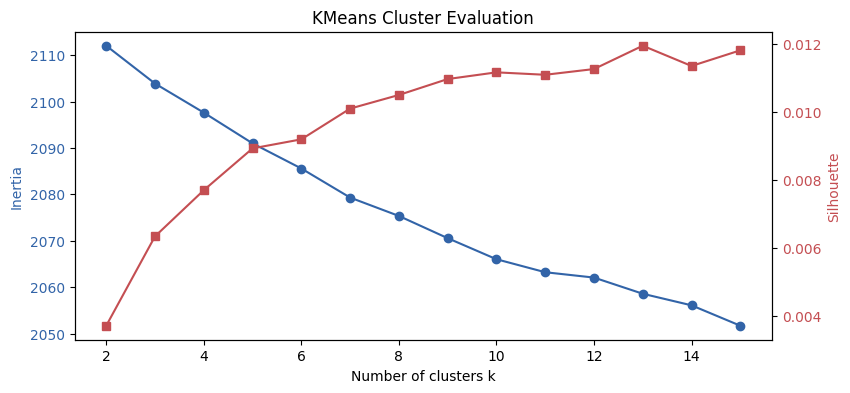

In [5]:
K_RANGE = range(2, 16)
metrics = []

for k in K_RANGE:
    model = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = model.fit_predict(X)
    sil = silhouette_score(X, labels, metric="cosine")
    metrics.append({"k": k, "inertia": model.inertia_, "silhouette": sil})

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(df_metrics["k"], df_metrics["inertia"], marker="o", color="#3264a8")
ax1.set_xlabel("Number of clusters k")
ax1.set_ylabel("Inertia", color="#3264a8")
ax1.tick_params(axis="y", labelcolor="#3264a8")

ax2 = ax1.twinx()
ax2.plot(df_metrics["k"], df_metrics["silhouette"], marker="s", color="#c44e52")
ax2.set_ylabel("Silhouette", color="#c44e52")
ax2.tick_params(axis="y", labelcolor="#c44e52")

plt.title("KMeans Cluster Evaluation")
plt.show()

## 5. 训练最终 KMeans 模型

运行上一步后，可以根据评估结果和主题可解释性修改 `N_CLUSTERS`。

In [6]:
N_CLUSTERS = 13

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20, max_iter=300)
df["cluster"] = kmeans.fit_predict(X)

cluster_counts = df["cluster"].value_counts().sort_index().rename_axis("cluster").reset_index(name="count")
display(cluster_counts)
print(f"最终 silhouette：{silhouette_score(X, df['cluster'], metric='cosine'):.4f}")

,cluster,count
0,0,97
1,1,471
2,2,152
3,3,119
4,4,272
5,5,54
6,6,48
7,7,189
8,8,110
9,9,263


最终 silhouette：0.0120


## 6. 提取每个簇的关键词

KMeans 的聚类中心可以反映每个簇中权重较高的 TF-IDF 特征。下面输出每个簇的 Top 关键词，用于人工命名主题。

In [7]:
def get_cluster_keywords(model, feature_names, top_n=15):
    rows = []
    order_centroids = model.cluster_centers_.argsort(axis=1)[:, ::-1]
    for cluster_id in range(model.n_clusters):
        keywords = feature_names[order_centroids[cluster_id, :top_n]].tolist()
        rows.append({
            "cluster": cluster_id,
            "count": int((df["cluster"] == cluster_id).sum()),
            "keywords": "、".join(keywords),
        })
    return pd.DataFrame(rows)

cluster_keywords = get_cluster_keywords(kmeans, terms, top_n=15)
display(cluster_keywords)

,cluster,count,keywords
0,0,97,还会、下次 还会、下次、还会 选择、选择、服务、花园酒店、满意、选择 花园酒店、体验、前台、...
1,1,471,花园酒店、服务、体验、博物馆、特别、前台、大堂、下次、选择、专业、喜欢、值得、这次、环境、五星级
2,2,152,服务、前台、小姐姐、一流、满意、前台 小姐姐、环境、花园酒店、周到、特别、装修、宾至如归、细...
3,3,119,就是、方便、地铁、服务、工作人员、服务 人员、人员、出行、出门、热情、位置、出行 方便、出门...
4,4,272,餐厅、瀑布、早餐、瀑布 餐厅、不错、博物馆、服务、就是、体验、荔湾、很多、好吃、自助、很棒、环境
5,5,54,交通 便利、便利、交通、服务、便利 出门、环境、地铁站、就是、位置、出门 就是、出门、不错、...
6,6,48,优越、地理位置、地理位置 优越、服务、花园酒店、方便、不错、地铁、早餐、选择、很大、位置 优...
7,7,189,干净、卫生、设施、服务、整洁、环境、干净 整洁、卫生 干净、舒适、齐全、设施 齐全、大堂、热...
8,8,110,五星、老牌、老牌 五星、不愧 老牌、服务、不愧、设施、老牌 五星级、不错、五星 服务、环境、...
9,9,263,不错、服务、环境、前台、有点、设施、环境 不错、浴缸、办理、就是、施工、早餐、一般、客房、大堂


## 7. 查看每个簇的代表评论

选择距离聚类中心最近的评论作为代表样本，辅助判断每个簇的主题含义。

In [8]:
distances = kmeans.transform(X)
representative_rows = []

for cluster_id in range(N_CLUSTERS):
    positions = np.where(df["cluster"].to_numpy() == cluster_id)[0]
    nearest_positions = positions[np.argsort(distances[positions, cluster_id])[:5]]
    for rank, pos in enumerate(nearest_positions, start=1):
        row = df.iloc[pos]
        representative_rows.append({
            "cluster": cluster_id,
            "rank": rank,
            "_id": row.name,
            "score": row.get("score", np.nan),
            "quality_score": row.get("quality_score", np.nan),
            "room_type": row.get("room_type", ""),
            "comment": row["comment"][:350],
        })

representatives = pd.DataFrame(representative_rows)
display(representatives)

,cluster,rank,_id,score,quality_score,room_type,comment
0,0,1,68027b0de3c98b0941765923,5.0,6,花园双床房,床垫很舒适，房间也很安静！入住过很多次了，很多房型都住过，每次去体验感都非常棒！下次还会选择推荐！
1,0,2,68027b39e3c98b094176594c,5.0,6,花园双床房,很好，出差广州第二次选择了！酒店很有底蕴，酒店工作人员很礼貌，又给升级了房间，挺好挺好！下次...
2,0,3,680280d2e3c98b0941765e0f,5.0,5,花园大床房,多次入住花园酒店，服务好，非常喜欢！粤韵房型近年装修，非常满意，下次还会选择花园酒店！\n设...
3,0,4,68027d10e3c98b0941765ada,5.0,6,花园大床房,酒店位置方便，硬件条件好，前台免费升级房型，非常感谢！下次来广州还会选择入住
4,0,5,6802835fe3c98b094176603e,5.0,7,羊羊得意主题大床房,酒店环境一流，干净舒服。多次入住，保持白金水准。孩子们很开心，在博物馆也学到很多知识，下次来...
...,...,...,...,...,...,...,...
60,12,1,68028073e3c98b0941765dc7,5.0,10,花园大床房,元宵节前特意坐高铁从深圳来到广州入住花园酒店。去年10月中旬入住时对酒店的行政酒廊体验很好，...
61,12,2,68028542e3c98b09417661ef,5.0,9,花园大床房,越秀区的广州花园酒店设施完善，性价比高，wifi给力，环境不错，地理位置好，离淘金地铁站非常...
62,12,3,68027b6de3c98b0941765972,5.0,7,花园大床房,行政酒廊 Cathy 和 Echo 服务很好，希望行政酒廊食物种类可以更丰富。还有回访的小颖...
63,12,4,68027b4ce3c98b094176595d,5.0,9,红棉双床套房,旧地重游『白金五星级酒店』：广州花园酒店，园林的建筑景观，定会让你宾至如归。每次下榻位于闹中...


## 8. 二维可视化

用 TruncatedSVD 将高维 TF-IDF 向量压缩到二维，仅用于直观观察，不作为严格评价依据。

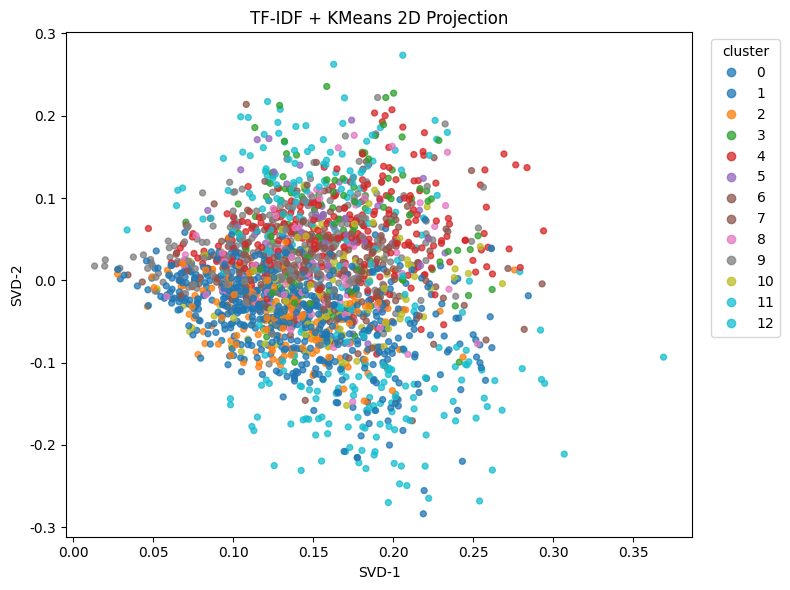

In [9]:
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=df["cluster"], cmap="tab10", s=18, alpha=0.75)
plt.legend(*scatter.legend_elements(), title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("TF-IDF + KMeans 2D Projection")
plt.xlabel("SVD-1")
plt.ylabel("SVD-2")
plt.tight_layout()
plt.show()

## 9. 保存结果

保存带聚类标签的评论数据、簇关键词汇总和代表评论，便于后续写报告或继续人工命名主题。

In [10]:
OUTPUT_CLUSTER_PATH = OUTPUT_DIR / "guangzhou_garden_hotel_tfidf_kmeans_clusters.csv"
OUTPUT_KEYWORDS_PATH = OUTPUT_DIR / "guangzhou_garden_hotel_tfidf_kmeans_cluster_keywords.csv"
OUTPUT_REPRESENTATIVES_PATH = OUTPUT_DIR / "guangzhou_garden_hotel_tfidf_kmeans_representatives.csv"

df.to_csv(OUTPUT_CLUSTER_PATH)
cluster_keywords.to_csv(OUTPUT_KEYWORDS_PATH, index=False)
representatives.to_csv(OUTPUT_REPRESENTATIVES_PATH, index=False)

print(f"Saved clusters: {OUTPUT_CLUSTER_PATH}")
print(f"Saved keywords: {OUTPUT_KEYWORDS_PATH}")
print(f"Saved representatives: {OUTPUT_REPRESENTATIVES_PATH}")

Saved clusters: tfidf_result/guangzhou_garden_hotel_tfidf_kmeans_clusters.csv
Saved keywords: tfidf_result/guangzhou_garden_hotel_tfidf_kmeans_cluster_keywords.csv
Saved representatives: tfidf_result/guangzhou_garden_hotel_tfidf_kmeans_representatives.csv
